<a href="https://colab.research.google.com/github/rafaeldebarros/MVP_analise_exploratoria/blob/main/MVP_An%C3%A1lise_explorat%C3%B3ria_de_dados_e_boas_pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de dados e boas práticas

Nome: Rafael Souza de Barros

Matrícula: 4052025001449

Dataset: Student Performance

## Descrição do problema e definição de hipóteses

Trata-se de análise exploratória de dados sobre resultados de estudantes em escolas secundárias (ensino médio) de duas instituições de ensino de Portugal (Gabriel Pereira ou Mousinho da Silveira) nas avaliações do 1º (G1), 2º (G2) e 3º (G3) períodos do último ano do ensino médio nas matérias de matemática e português. O dataset possui 30 variáveis, além das 3 variáveis alvo, relacionadas a questões demográficas, sociais e escolares dos alunos e foram obtidas mediante relatórios e questionários escolares, tendo acesso público em https://archive.ics.uci.edu/dataset/320/student+performance.

O objetivo da presente análise é tratar a base de dados, a fim de identificar as variáveis que tenham maior correlação com os resultados obtidos pelos estudantes secundaristas nas avaliações escolares da amostra obtida.

O problema que se coloca nessa análise é um problema de regressão, pois visa identificar em que medida cada variável pode servir para explicar ou prever a nota dos alunos, tratando-se, portanto, de um problema de aprendizado supervizionado.

Inicialmente, têm-se como hipótese que o tempo de estudo, o suporte familiar e a frequência as aulas são as variáveis com maior influência nos resultados obtidos.

### Importando as bibliotecas necessárias

In [61]:


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler


### Importando Arquivos CSV do GitHub para o Colab



A importação foi realizada com sucesso, constando 33 colunas, sendo 30 de variáveis explicativas e 3 de variáveis alvo, apresentando a nota obtida por cada aluno em cada uma das matéria nos 3 períodos que o ano letivo é dividido.

In [62]:
import pandas as pd

csv_url_mat = "https://raw.githubusercontent.com/rafaeldebarros/MVP_analise_exploratoria/refs/heads/main/student/student-mat.csv"
csv_url_por = "https://raw.githubusercontent.com/rafaeldebarros/MVP_analise_exploratoria/refs/heads/main/student/student-por.csv"


dados_mat = pd.read_csv(csv_url_mat, sep=';')
display(dados_mat.head())

dados_por = pd.read_csv(csv_url_por, sep=';')
display(dados_por.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


### Unindo os DataFrames e Adicionando Coluna de Matéria

Para trabalhar os dados mais facilmente unificarei as tabelas, criando uma nova coluna para identifar qual a matéria que as notas das avaliações se referem, sem perder informações relevantes

Agora o dataframe passa a ter 34 colunas.

In [63]:
# Adicionar uma coluna 'subject' para identificar a origem dos dados
dados_mat['subject'] = 'mat'
dados_por['subject'] = 'por'

# Unir os dois dataframes
df_combinado = pd.concat([dados_mat, dados_por], ignore_index=True)

display(df_combinado.head())


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


### Analisando os tipos de variáveis no *dataframe*

Abaixo observamos que muitas das colunas classificadas como numéricas (int64) são, na realidade, categóricas (object), mas usam números para enquadrar as informações nas diferentes categorias.

Não obstante essa informação, observo que as variáveis reconhecidas como numéricas, mesmo sendo categóricas, possuem uma divisão em números crescente. Por exemplo, na coluna 'traveltime' consta informações sobre o tempo que o aluno gasta no percurso de casa para a escola, sendo 1 = menos de 15 minutos, 2 = entre 15 e 30 minutos, 3= entre 30 e 60 minutos e 4 = mias de 60 minutos.

Assim, as variáveis catérgoricas reconhecidas como numéricas são do tipo ordinais, o que faz com que os números atribuídos possuam relação com a ordem de grandeza dos dados originalmente considerados. Com isso, opto por manter os dados dessa forma, pois a análise de correlação poderá considerar a ordem de grandeza, mesmo que não considere o intervalo propriamente considerado.

In [64]:

print('\nTipos de variáveis no dataframe:')
print(df_combinado.dtypes)


Tipos de variáveis no dataframe:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
subject       object
dtype: object


### Verificando Valores Ausentes no DataFrame

Observa-se que não há valores faltantes no banco de dados, por isso, não será necessário utilizar técnicas de tratamento de dados para tratar os *missing values*

---



In [65]:
print("Valores ausentes no dataframe:")
display(df_combinado.isnull().sum())



Valores ausentes no dataframe:


,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


### Estatísticas Descritivas para Todas as Variáveis

Analisando as estatísticas descritivas de todas as colunas do dataframe identificamos que temos 1.044 observações para todas as variáveis.

Muitas variáveis são categóricas, mesmo quando utilizam número para identifcar categorias e as variáveis alvo são numéricas (notas), com médias muito similares próximas a 11, sendo o valor mínico 0 e máximo 20.

A existência de 3 variáveis alvo pode ocasionar algumas dificuldades no momento da análise e gerar maior complexidade para aplicar e interpretar modelos de regressão. Levando em consideração, ainda, que elas possuem um valor médio muito próximo e possuem o mesmo valor máximo e mínimo, entendo eficiente criar uma nova variável, denominada 'média final', para trabalhar com apenas uma variável alvo.

A seguir apresento gráficos de distribuição de cada atributo do *dataframe*.

In [66]:
print(df_combinado.describe(include='all'))

       school   sex          age address famsize Pstatus         Medu  \
count    1044  1044  1044.000000    1044    1044    1044  1044.000000   
unique      2     2          NaN       2       2       2          NaN   
top        GP     F          NaN       U     GT3       T          NaN   
freq      772   591          NaN     759     738     923          NaN   
mean      NaN   NaN    16.726054     NaN     NaN     NaN     2.603448   
std       NaN   NaN     1.239975     NaN     NaN     NaN     1.124907   
min       NaN   NaN    15.000000     NaN     NaN     NaN     0.000000   
25%       NaN   NaN    16.000000     NaN     NaN     NaN     2.000000   
50%       NaN   NaN    17.000000     NaN     NaN     NaN     3.000000   
75%       NaN   NaN    18.000000     NaN     NaN     NaN     4.000000   
max       NaN   NaN    22.000000     NaN     NaN     NaN     4.000000   

               Fedu   Mjob   Fjob  ...     freetime        goout         Dalc  \
count   1044.000000   1044   1044  ...  10

### Análise da distribuição dos dados

Distribuição da amostra por sexo

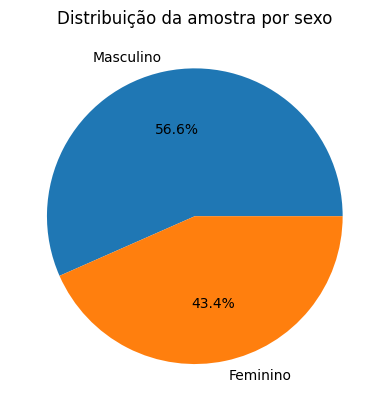

In [67]:

### Distribuição da amostra por sexo
plt.pie(df_combinado['sex'].value_counts(), labels=['Masculino', 'Feminino'], autopct='%1.1f%%')
plt.title('Distribuição da amostra por sexo')
plt.show()

Pelo gráfico de pizza, observamos que a maior parte dos respondentes são do sexo masculino, mas não há uma desproporção tão elevada por essa variável.

Distribuição da amostra por faixa etária

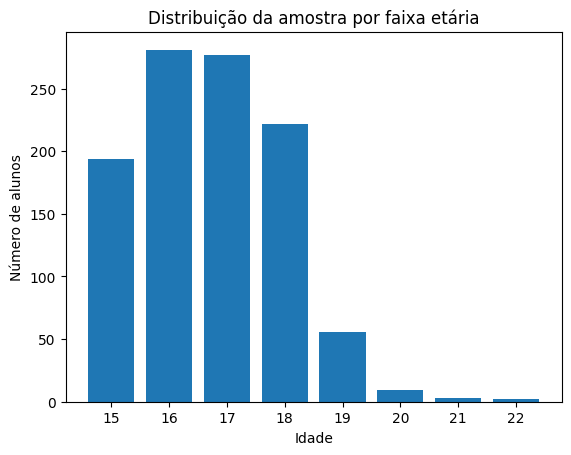

In [68]:
### Distribuição da amostra por faixa etária
age_counts = df_combinado['age'].value_counts().sort_index()
plt.bar(age_counts.index, age_counts.values)
plt.title('Distribuição da amostra por faixa etária')
plt.xlabel('Idade')
plt.ylabel('Número de alunos')
plt.show()

Observamos que a grande maioria da amostra possui idade entre 16 e 18, o que é um resultado esperado, já que essa faixa etária é a mais comum no último ano do ensino médio.

Distribuição dos dados por matéria de avaliação

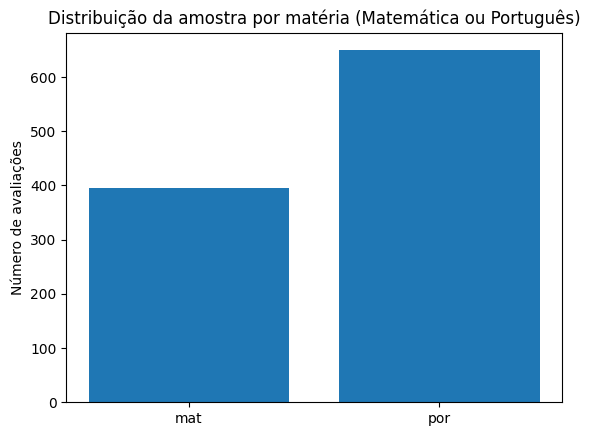

In [69]:
subject_counts = df_combinado['subject'].value_counts().sort_index()
plt.bar(subject_counts.index, subject_counts.values)
plt.title('Distribuição da amostra por matéria (Matemática ou Português)')
plt.ylabel('Número de avaliações')
plt.show()

Observa-se que temos mais avaliações de português que de matemática na amostra. A seguir, ao fazer a análise das estatísticas descritivas e das correlações, será avaliado possível impacto desse desbalanceamento.

Distribuição das demais variáveis

/tmp/ipykernel_26953/272304193.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_combinado, x=col, ax=ax, palette='viridis')
/tmp/ipykernel_26953/272304193.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_combinado, x=col, ax=ax, palette='viridis')
/tmp/ipykernel_26953/272304193.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_combinado, x=col, ax=ax, palette='viridis')
/tmp/ipykernel_26953/272304193.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in

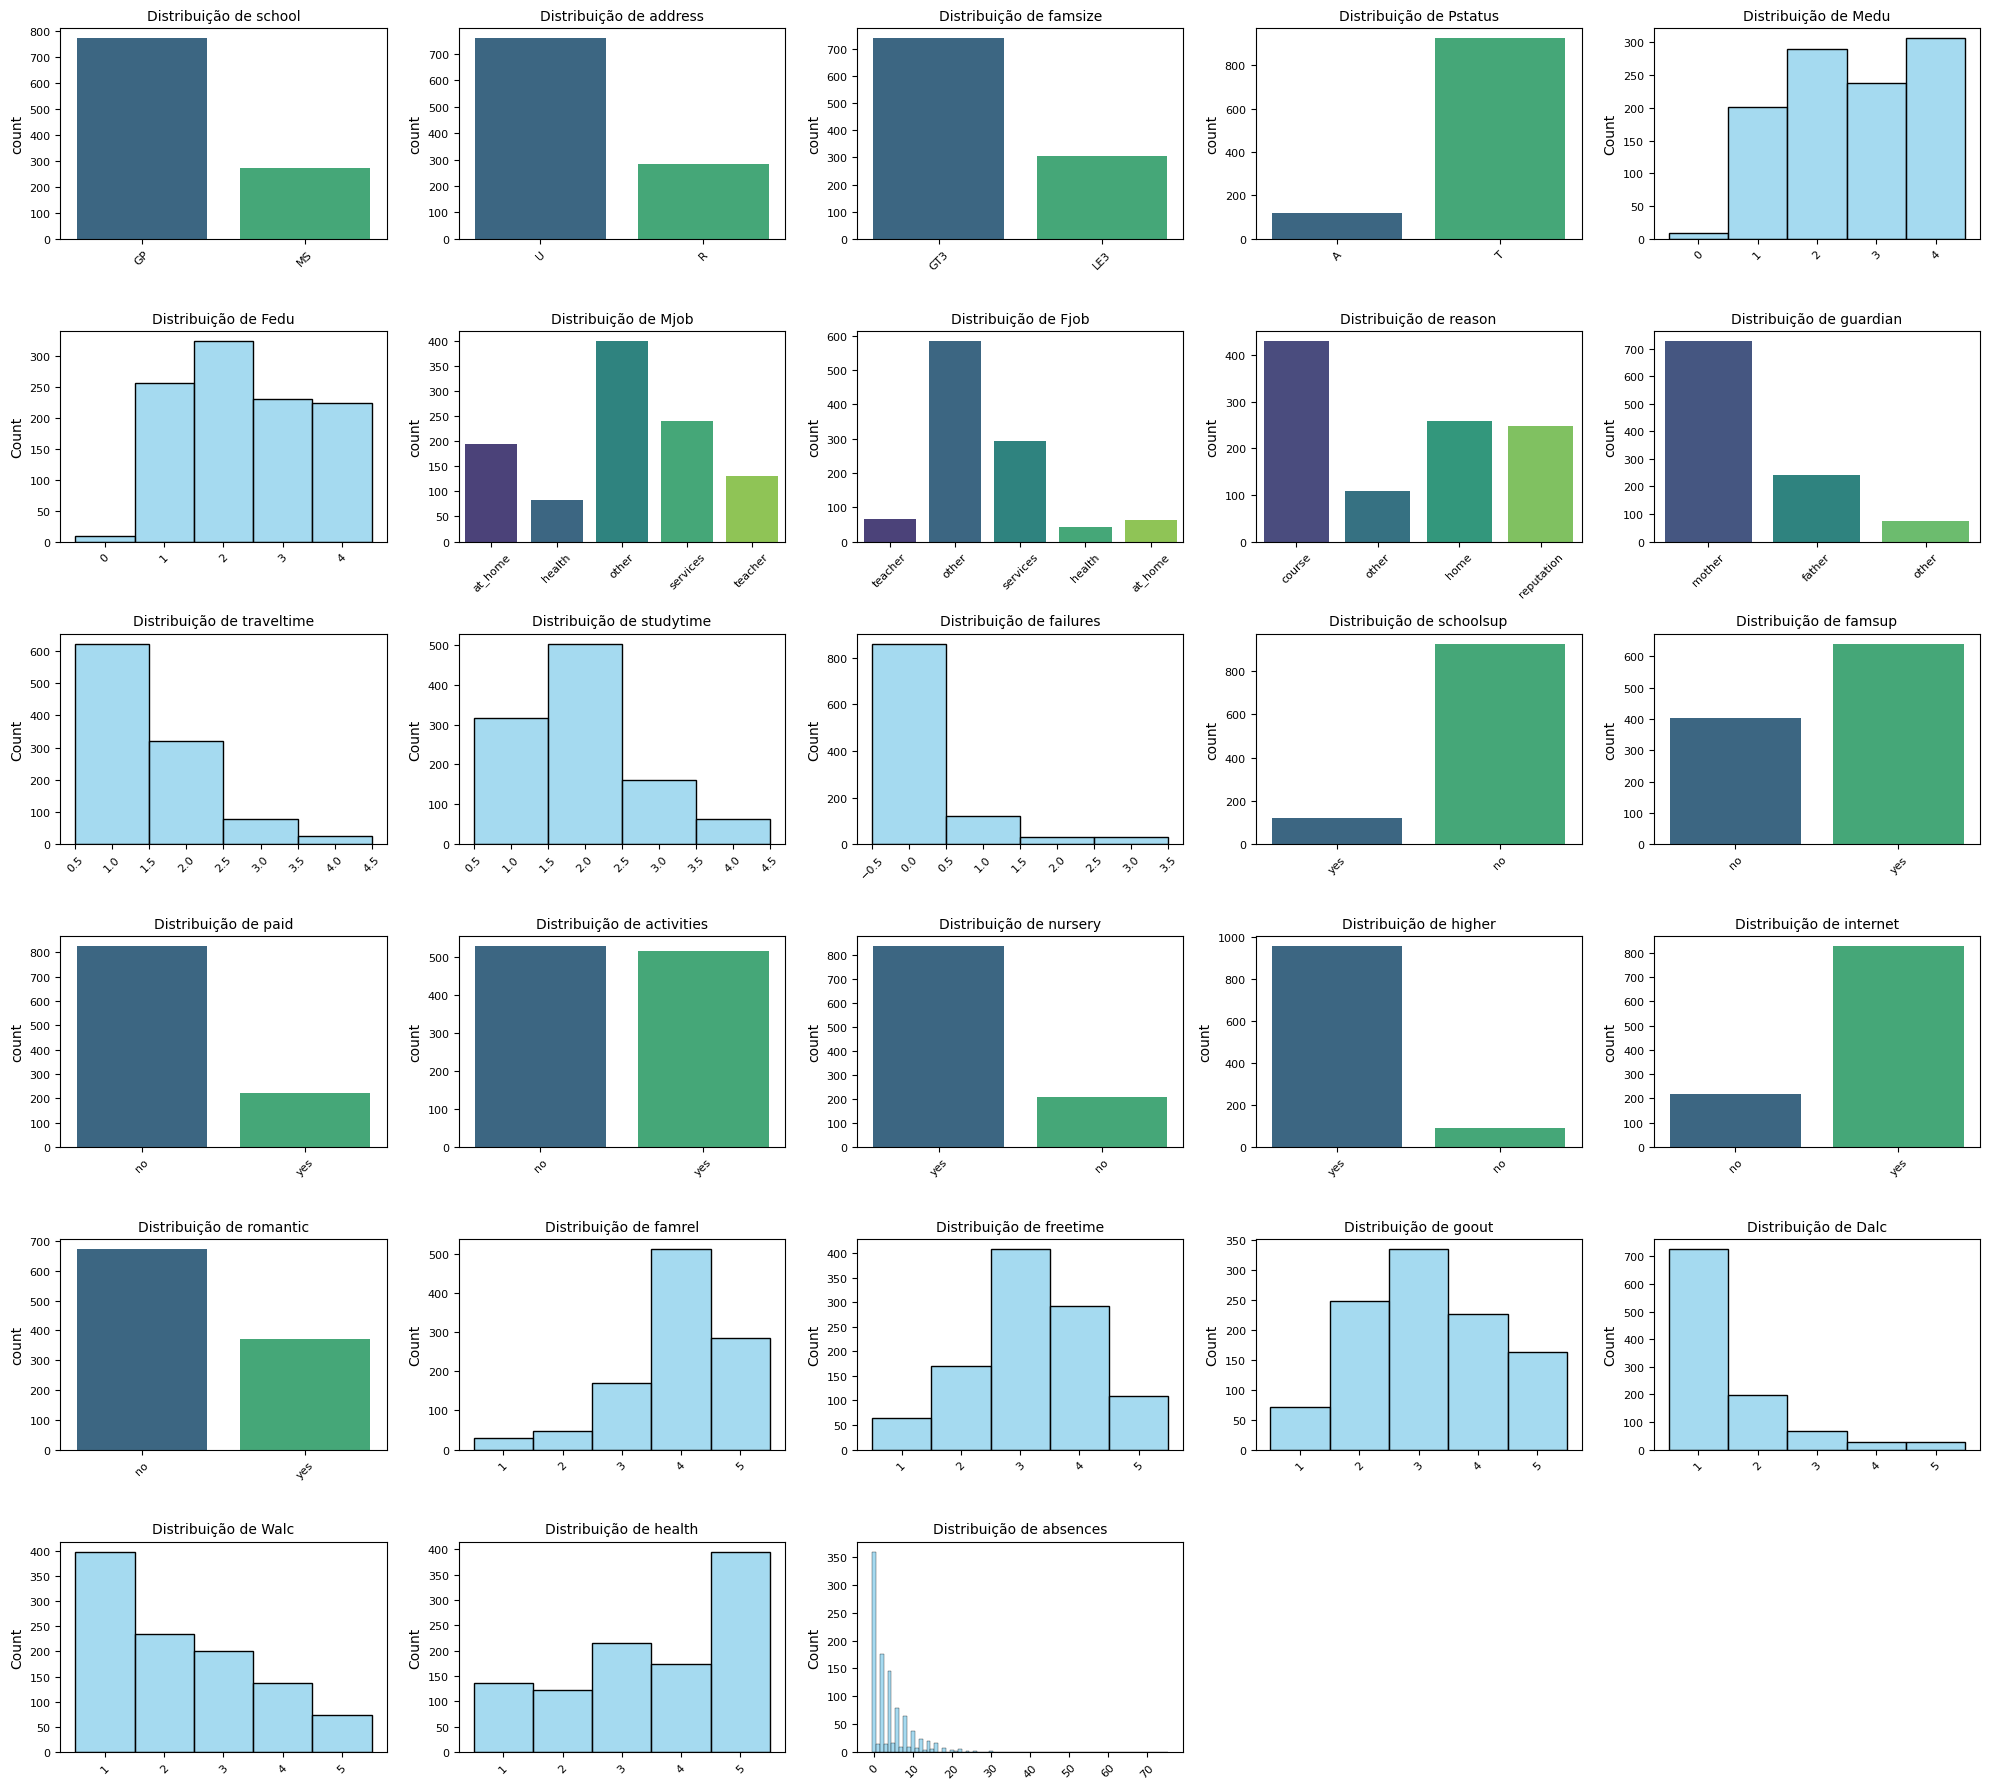

In [70]:
variables_to_exclude = ['sex', 'age', 'subject', 'G1', 'G2', 'G3', 'media final']
all_columns = df_combinado.columns.tolist()
columns_to_plot = [col for col in all_columns if col not in variables_to_exclude]

num_vars = len(columns_to_plot)
num_cols = 5
num_rows = (num_vars + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 4, num_rows * 3))

for i, col in enumerate(columns_to_plot):
    ax = plt.subplot(num_rows, num_cols, i + 1)
    if df_combinado[col].dtype == 'object':
        sns.countplot(data=df_combinado, x=col, ax=ax, palette='viridis')
    else:
        sns.histplot(data=df_combinado, x=col, ax=ax, discrete=True, color='skyblue')
    ax.set_title(f'Distribuição de {col}', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

Aqui temos os gráficos de distribuição de todas as demais variáveis.

Verifica-se que quase nenhum atributo possui dstribuição normal, mas como eles são variáveis categóricas, em sua maioria, isso não é necessariamente um problema, pois pode ser uma característica dos dados coletados e não influenciar negativamente na correlação ou na capacidade preditiva do modelo de regressão.

### Criando nova variável *target*: "media final" e analisando as estatísticas descritivas

Como comentado acima, criarei uma nova variável para ser a *target*, correspondendo a média das três notas de cada avaliação feita no ano letivo.

Agora passamos a ter 35 colunas no dataframe, mas iremos usar apenas 1 variável como *target*, que será a média final.

O valor da média ficou muito próxima das outras avaliações, além de termos uma observação global das avaliações de todo o ano, o que é mais condizente com as variáveis explicativas que não consideram diferentes períodos do ano.  



In [71]:
# Criar a nova variável target 'media final' como a média de G1, G2 e G3 e arredondar para inteiro
df_combinado['media final'] = df_combinado[['G1', 'G2', 'G3']].mean(axis=1).round(0)

print("Nova variável target 'media final' criada no dataframe 'y'.")
display(df_combinado.head())

print(df_combinado.describe(include='all'))

Nova variável target 'media final' criada no dataframe 'y'.


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,subject,media final
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,mat,6.0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,mat,5.0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,mat,8.0
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,15,mat,15.0
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,10,mat,9.0


       school   sex          age address famsize Pstatus         Medu  \
count    1044  1044  1044.000000    1044    1044    1044  1044.000000   
unique      2     2          NaN       2       2       2          NaN   
top        GP     F          NaN       U     GT3       T          NaN   
freq      772   591          NaN     759     738     923          NaN   
mean      NaN   NaN    16.726054     NaN     NaN     NaN     2.603448   
std       NaN   NaN     1.239975     NaN     NaN     NaN     1.124907   
min       NaN   NaN    15.000000     NaN     NaN     NaN     0.000000   
25%       NaN   NaN    16.000000     NaN     NaN     NaN     2.000000   
50%       NaN   NaN    17.000000     NaN     NaN     NaN     3.000000   
75%       NaN   NaN    18.000000     NaN     NaN     NaN     4.000000   
max       NaN   NaN    22.000000     NaN     NaN     NaN     4.000000   

               Fedu   Mjob   Fjob  ...        goout         Dalc         Walc  \
count   1044.000000   1044   1044  ...  10

Analisando as estatísticas descritivas, filtrando pela matéria de avaliação (Matemática ou Português), observa-se que a média da nota final para matemática é um pouco inferior a alcançada na prova de português. A diferença está nas notas dos 1º e 2º quartis, que são mas baixas nas avaliações de matemática.

In [72]:
# Filtrar o DataFrame para 'mat' (matemática)
df_mat = df_combinado[df_combinado['subject'] == 'mat']
print("\nEstatísticas Descritivas para a matéria de Matemática:")
display(df_mat.describe(include='all'))

# Filtrar o DataFrame para 'por' (português)
df_por = df_combinado[df_combinado['subject'] == 'por']
print("\nEstatísticas Descritivas para a matéria de Português:")
display(df_por.describe(include='all'))


Estatísticas Descritivas para a matéria de Matemática:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,subject,media final
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mat,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,395,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,...,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,NaN,10.660759
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,...,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,NaN,3.719390
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,NaN,1.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,NaN,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,NaN,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,NaN,13.000000



Estatísticas Descritivas para a matéria de Português:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,subject,media final
count,649,649,649.000000,649,649,649,649.000000,649.000000,649,649,...,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649,649.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,por,NaN
freq,423,383,NaN,452,457,569,NaN,NaN,258,367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,649,NaN
mean,NaN,NaN,16.744222,NaN,NaN,NaN,2.514638,2.306626,NaN,NaN,...,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009,NaN,11.630200
std,NaN,NaN,1.218138,NaN,NaN,NaN,1.134552,1.099931,NaN,NaN,...,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656,NaN,2.840744
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,...,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000,NaN,10.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000,NaN,12.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000,NaN,13.000000


### Aplicação de one-hot enconding e plotagem de mapa de calor



Considerando que o *dataframe* possui algumas colunas com dados categóricos que não foram tratados para a análise de correlação, é necessário aplicar a técnica do *one-hot encoding*, como forma de criar variável binária, que é mais facilmente compreendida e processada por sistema computacional.

In [73]:
# Identificar colunas categóricas no dataframe
categorical_cols = df_combinado.select_dtypes(include=['object']).columns

# Aplicar One-Hot Encoding nas colunas categóricas
df_encoded = pd.get_dummies(df_combinado, columns=categorical_cols, drop_first=True)

Em seguida vou gerar um mapa de calor, para avaliar a correlação de todas as *features* com a nossa *target*, a fim de entender quais atributos poderão contribuir mais na construção de um modelo de regressão.

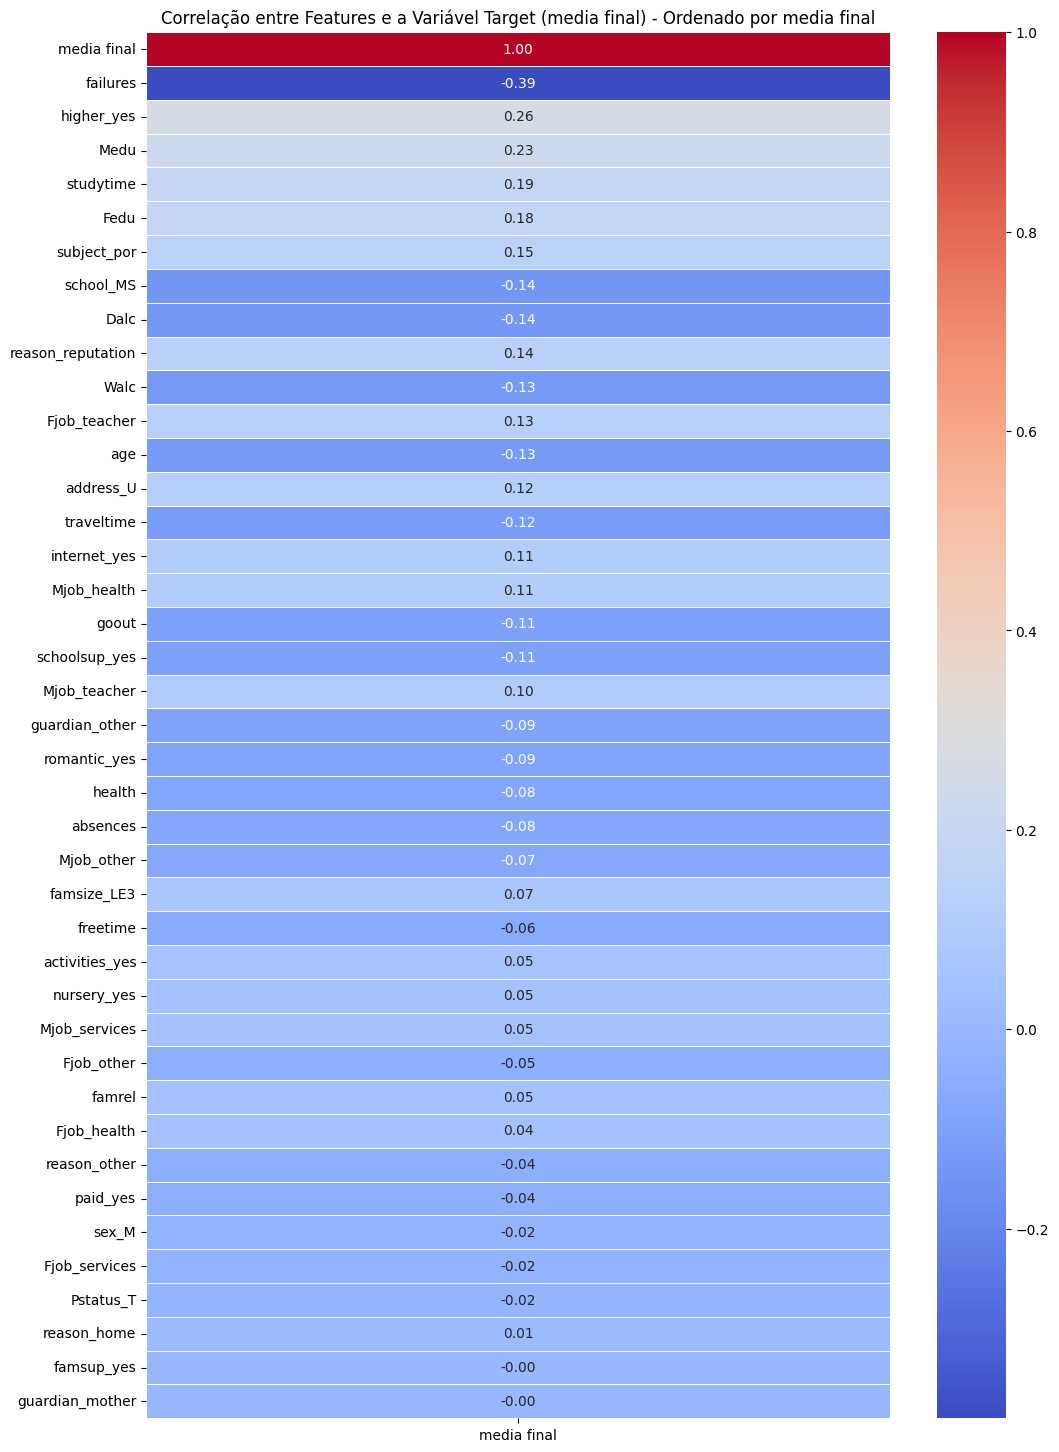

In [74]:

# Calcular a matriz de correlação
correlation_matrix = df_encoded.corr()

# Selecionar apenas as correlações com a variável target 'media final'
target_correlations = correlation_matrix[['media final']]

# Ordenar a matriz de correlação pela correlação absoluta com 'media final' em ordem decrescente
target_correlations_sorted = target_correlations.loc[target_correlations['media final'].abs().sort_values(ascending=False).index]

target_correlations_sorted = target_correlations_sorted.drop(['G1', 'G2', 'G3'], errors='ignore')

# Plotar o heatmap das correlações com o target
plt.figure(figsize=(12, 18))
sns.heatmap(target_correlations_sorted, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação entre Features e a Variável Target (media final) - Ordenado por media final')
plt.show()

Podemos perceber que, pela fórmula de correlação de Pearson, adotada no *heatmap*, o atributo mais correlacionado com a média final é o número de reprovações tidas pelo aluno nas matérias passadas, que está intimamente relacionada com a nota. Essa é uma correlação negativa, ou seja, enquanto maior as reprovações menor a média final e vice-versa.

As demais variáveis possuem correlação menor, chamando a atenção o interesse de ir para um curso de ensino superior (universidade), o grau de escolaridade da mãe e o tempo de estudo semanal.

No entanto, a amioria das correlações são mmuito fracas, sendo necessário tentar novas técnicas para aumentar essas correlações.

### Criando novas variáveis

Considerando a baixa correlação encontrada em muitas variáveis, uma técnica possível para tentar aumentar essa correlação é associar variáveis.

Assim, decidi criar uma variável chamada 'Alc_total', que corresponde ao consumo de álcool na semana (considerando final de semana e dias úteis).

Além dela, criei três novas variáveis relacionando o grau de escolaridade dos pais, denominada 'Parentedu_', sendo 'Parentedu_sum' a soma do grau do pai e da mãe, 'Parentedu_avg' a média do grau de escolaridade do pai e da mãe e 'Parentedu_max' o valor máximo encontrado na escolaridade do pai ou da mãe.

E, por fim, criei duas variáveis associando o histórico de reprovações com o suporte escolar (aulas de reforço escolar). A coluna 'school_history' soma esses atributos e 'failures_with_schoolsup' agrega as informações de reprovação com o reforço escolar.

In [75]:
# Criar uma cópia do dataframe codificado para adicionar novas features
df_novas_var = df_encoded.copy()

# 1. Consumo Total de Álcool
df_novas_var['Alc_total'] = df_novas_var['Dalc'] + df_novas_var['Walc']

# 2. Educação Parental Combinada
df_novas_var['Parentedu_sum'] = df_novas_var['Medu'] + df_novas_var['Fedu']
df_novas_var['Parentedu_avg'] = (df_novas_var['Medu'] + df_novas_var['Fedu']) / 2
df_novas_var['Parentedu_max'] = df_novas_var[['Medu', 'Fedu']].max(axis=1)

# 3. Histórico Escolar (combinando reprovações e reforço escolar)
df_novas_var['school_history'] = df_novas_var['failures'] + (df_novas_var['schoolsup_yes'] * -1)
df_novas_var['failures_with_schoolsup'] = df_novas_var['failures'] * df_novas_var['schoolsup_yes']


display(df_novas_var.head())

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,higher_yes,internet_yes,romantic_yes,subject_por,Alc_total,Parentedu_sum,Parentedu_avg,Parentedu_max,school_history,failures_with_schoolsup
0,18,4,4,2,2,0,4,3,4,1,...,True,False,False,False,2,8,4.0,4,-1,0
1,17,1,1,1,2,0,5,3,3,1,...,True,True,False,False,2,2,1.0,1,0,0
2,15,1,1,1,2,3,4,3,2,2,...,True,True,False,False,5,2,1.0,1,2,3
3,15,4,2,1,3,0,3,2,2,1,...,True,True,True,False,2,6,3.0,4,0,0
4,16,3,3,1,2,0,4,3,2,1,...,True,False,False,False,3,6,3.0,3,0,0


### Reavaliando Correlações com Novas Features

Agora vou plotar novamente o mapa de calor com as novas variáveis criadas.

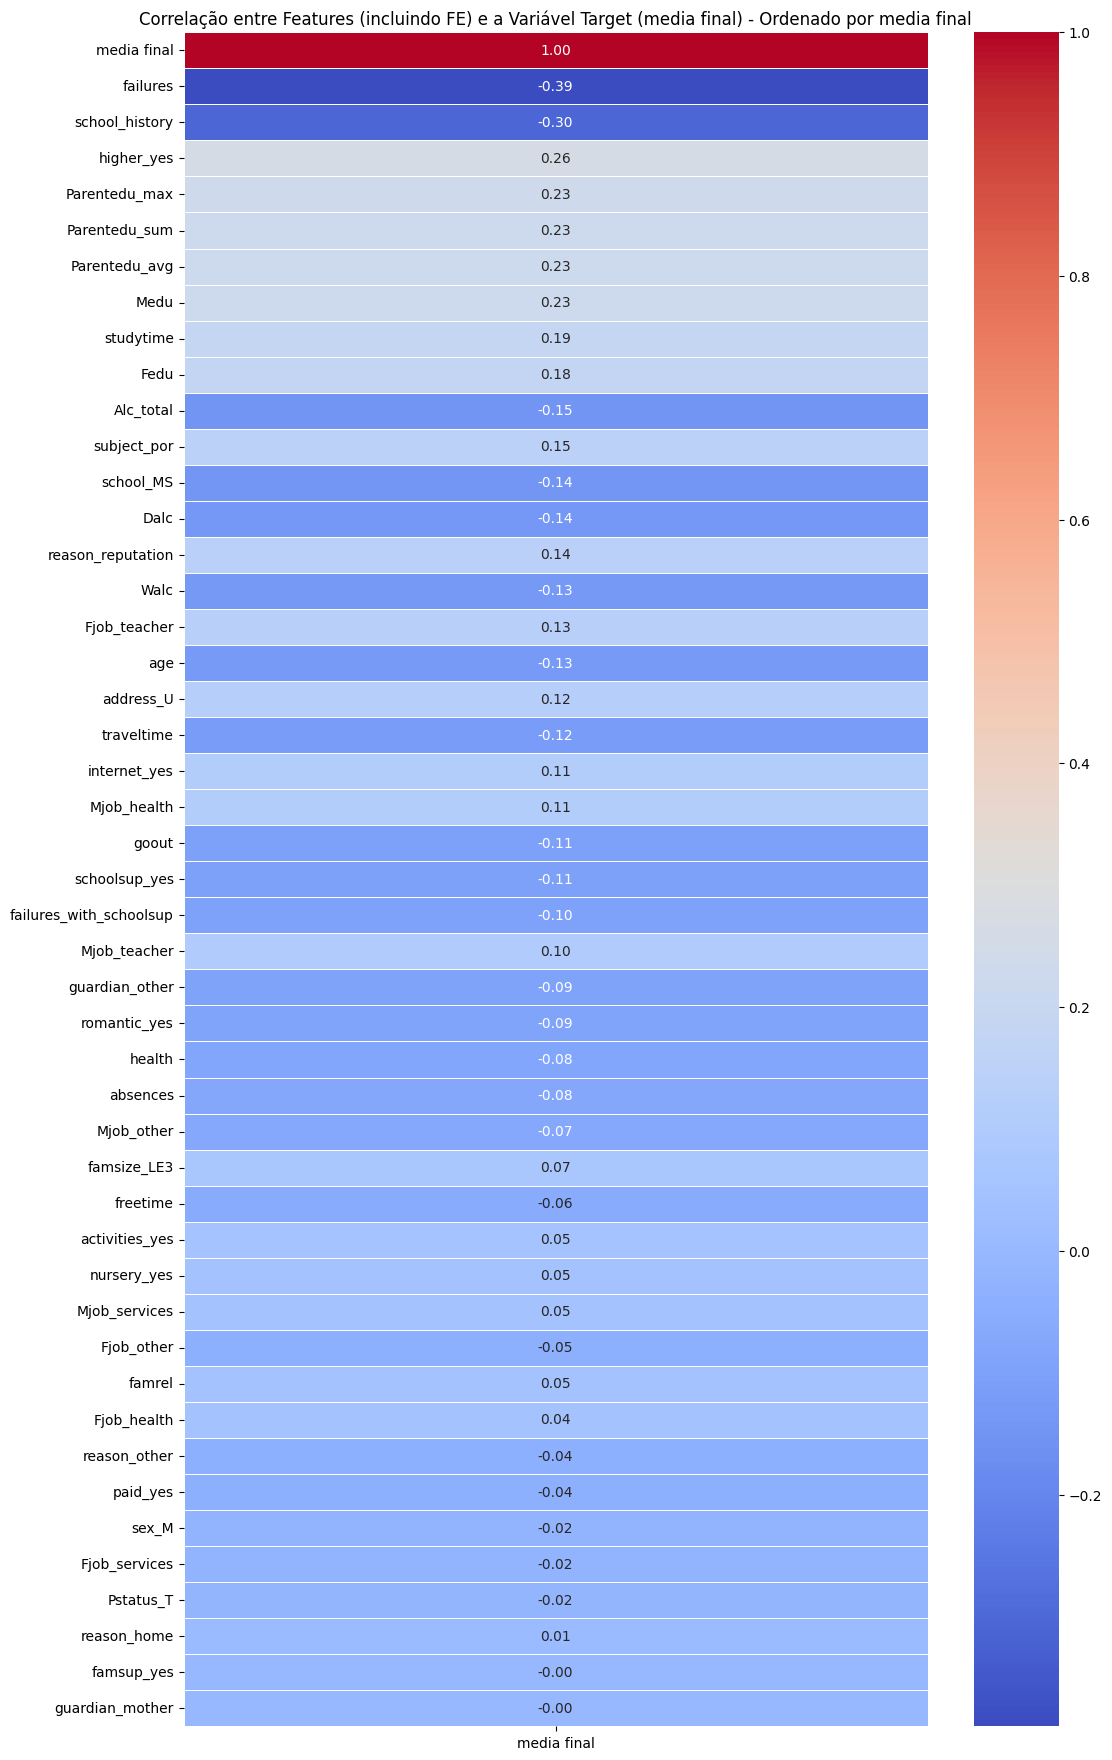

Top 20 features mais correlacionadas com 'media final' após engenharia de features:
failures            -0.390212
school_history      -0.304964
higher_yes           0.261485
Parentedu_max        0.233554
Parentedu_sum        0.226650
Parentedu_avg        0.226650
Medu                 0.225589
studytime            0.189784
Fedu                 0.184697
Alc_total           -0.148955
subject_por          0.145435
school_MS           -0.144222
Dalc                -0.139786
reason_reputation    0.138320
Walc                -0.131306
Fjob_teacher         0.127381
age                 -0.127104
address_U            0.121760
traveltime          -0.119439
internet_yes         0.114029
Name: media final, dtype: float64


In [76]:


# Calcular a matriz de correlação
correlation_matrix_fe = df_novas_var.corr()

# Selecionar apenas as correlações com a variável target 'media final'
target_correlations_fe = correlation_matrix_fe[['media final']]

# Ordenar a matriz de correlação pela correlação absoluta com 'media final' em ordem decrescente
target_correlations_sorted_fe = target_correlations_fe.loc[target_correlations_fe['media final'].abs().sort_values(ascending=False).index]
target_correlations_sorted_fe = target_correlations_sorted_fe.drop(['G1', 'G2', 'G3'], errors='ignore')


# Plotar o heatmap das correlações com o target, incluindo as novas features
plt.figure(figsize=(12, 22))
sns.heatmap(target_correlations_sorted_fe, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação entre Features (incluindo FE) e a Variável Target (media final) - Ordenado por media final')
plt.show()

print("Top 20 features mais correlacionadas com 'media final' após engenharia de features:")
print(target_correlations_sorted_fe['media final'].drop(['G1', 'G2', 'G3', 'media final'], errors='ignore').head(20))

Do gráfico acima, observa-se que a variável sobre consumo semanal de álcool aumentou minimamente a correlação em relação aos atributos associados.

As novas variáveis de grau educacional dos pais não obtiveram melhor nível de correlação do já alcançado pelo grau de escolaridade da mãe (Medu).

E as variáveis de histórico escolar tiveram enfraquecidas suas correlações.

Em relação a esse último ponto, uma conclusão interessante que se pode extrair é que o reforço escolar (schoolsup_yes) reduz a negatividade das reprovações, o que quer dizer que realmente obtém um resultado positivo na melhoria do aprendizado.



### Gráficos de dispersão das 9 variáveis mais correlacionadas com a média final

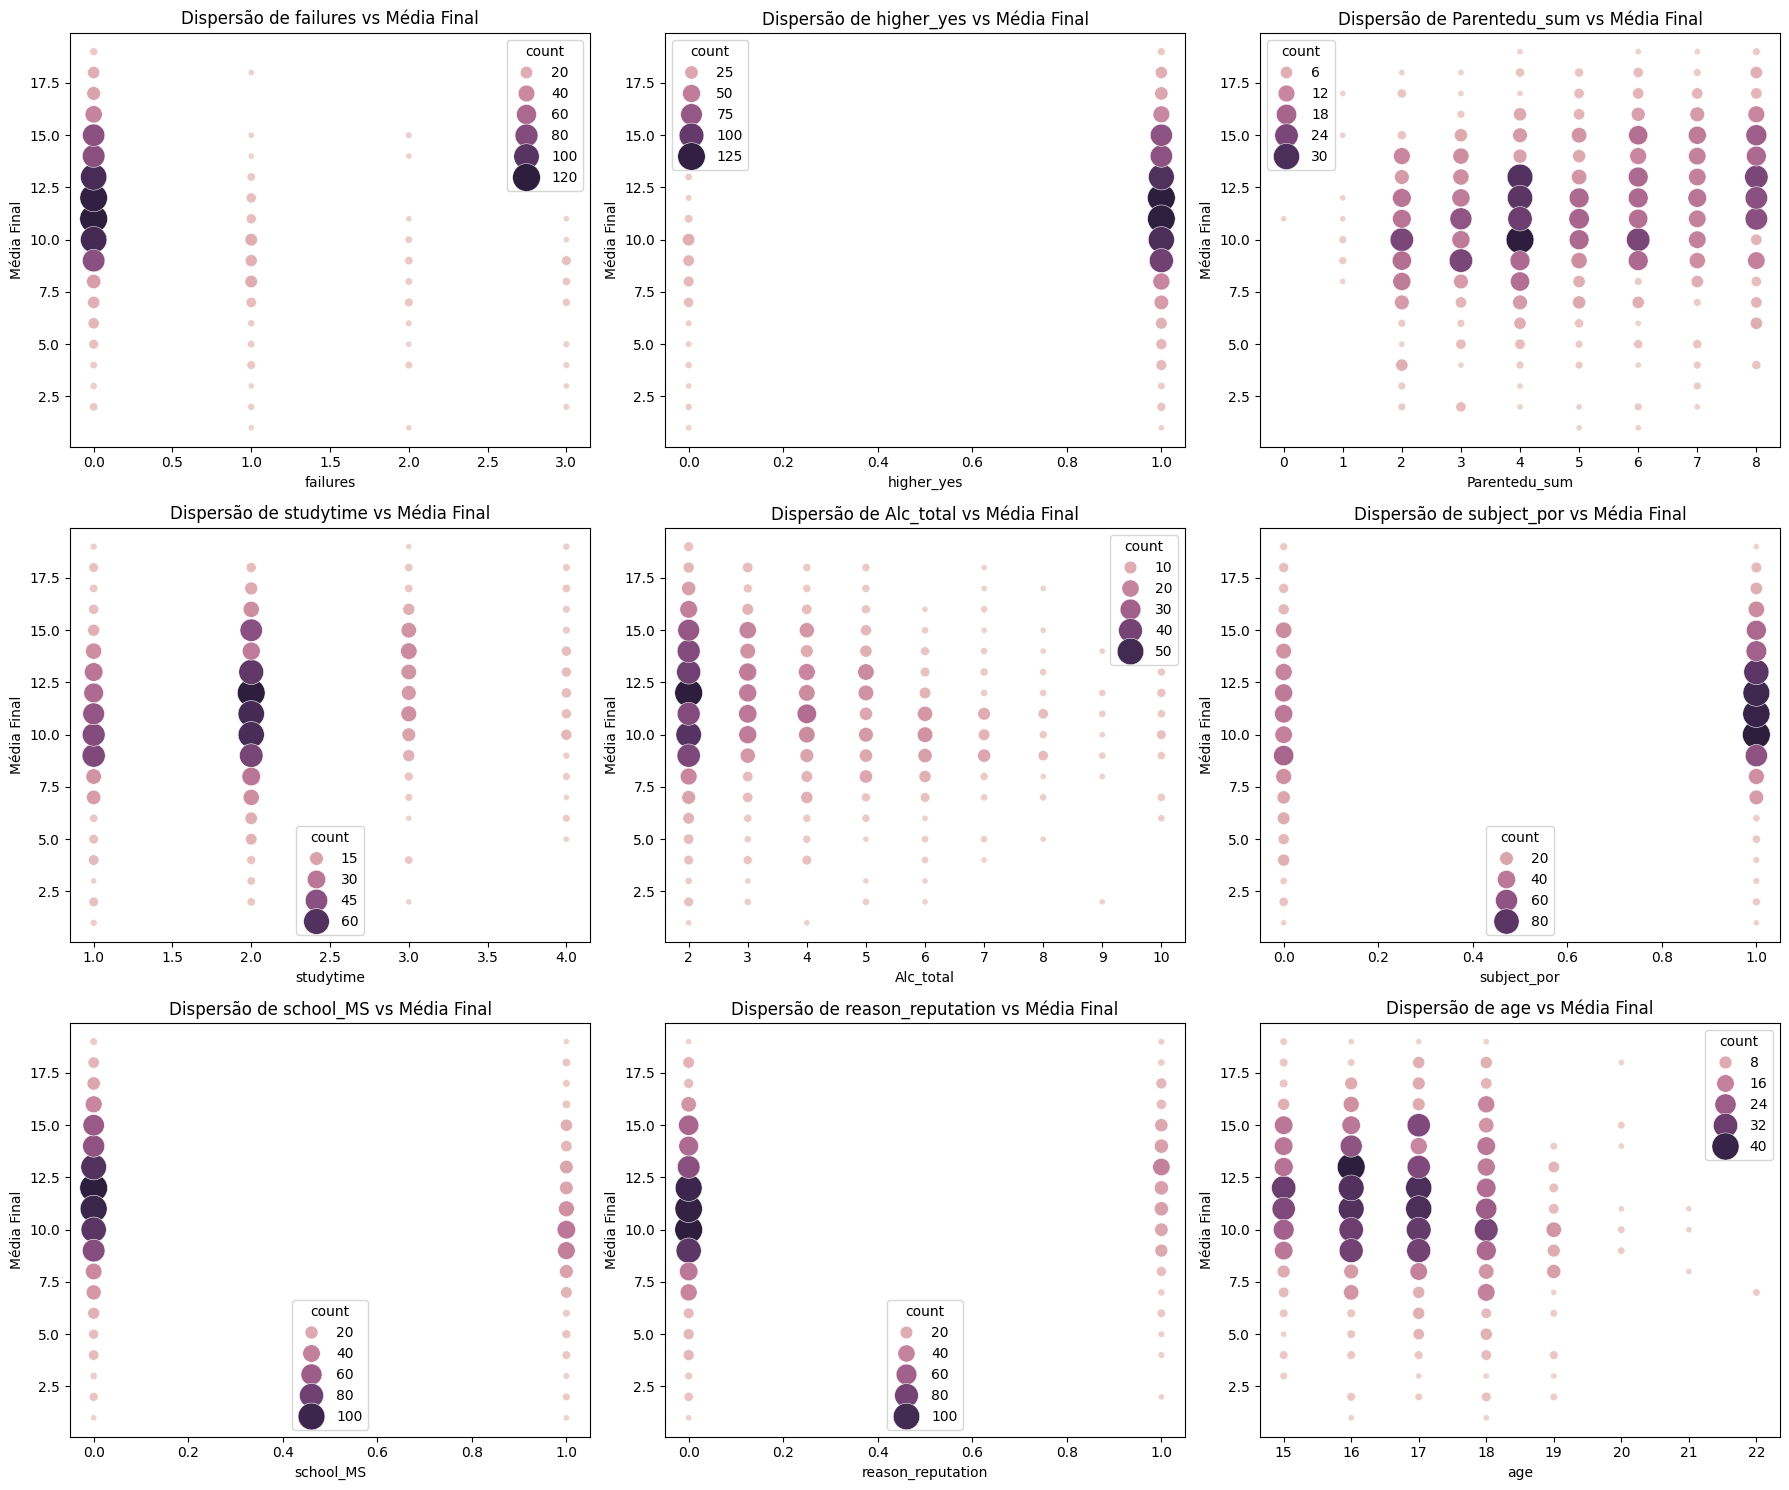

In [77]:

# Determinar o número de linhas e colunas para os subplots
columns_to_plot = ('failures', 'higher_yes', 'Parentedu_sum',
                   'studytime', 'Alc_total', 'subject_por',
                   'school_MS', 'reason_reputation', 'age')
num_vars = len(columns_to_plot)
num_rows = (num_vars + 2) // 3
num_cols = 3

#Criar figura onde serão inseridos os subplots
plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, col in enumerate(columns_to_plot):
    plt.subplot(num_rows, num_cols, i + 1)

    # Calcular a contagem de cada combinação para o tamanho dos pontos
    plot_data = df_novas_var[[col, 'media final']].value_counts().reset_index(name='count')

    #Plotar gráfico de dispersão
    sns.scatterplot(x=plot_data[col], y=plot_data['media final'], size=plot_data['count'], sizes=(20, 400), hue=plot_data['count'], legend='brief')
    plt.title(f'Dispersão de {col} vs Média Final')
    plt.xlabel(col)
    plt.ylabel('Média Final')

plt.tight_layout()
plt.show()

Do gráfico de dispersão acima, pode-se tirar algumas conclusões que não são tão óbvias analisando apenas o índice de correlação.

Um que chama bastante a atenção é o do tempo de estudo semanal (studytime), no qual se observa que o incremento desse tempo da categoria (1) - menos de 2 horas por semana - para a categroria (2) - de 2 a 5 horas semanais - e para a categoria (3) - de 5 a 10 horas de estudos todas as semanas - tem como resultado a elevação da média da maioria dos alunos nessas categorias. No entanto, essa premissa não é verdadeira para os alunos da categoria (4) - de mais de 10 horas semanais-, que se concentram em uma faixa da média final equivalente aos alunos da categoria (1).

Isso pode indicar um ponto ótimo de período de estudo na categoria (3) - de 5 a 10 horas de estudo por semana.

Uma outra conclusão que se pode chegar é a de constante acréscimo na média da maioria dos alunos quanto maior é o grau de escolaridade dos pais combinados.

Essa constatação sinaliza que de algum modo os pais com maior formação educacional concedem maior suporte aos filhos, mesmo que essa informação não apareça no atributo de suporte familiar.



### Matriz de correlação das 9 variáveis selecionadas

Irei plotar agora a matriz de correlação apenas das 9 variáveis selecioandas acima, para avaliação de multicolinearidade entre as features, que poderiam violar as premissas de um modelo de regressão linear.

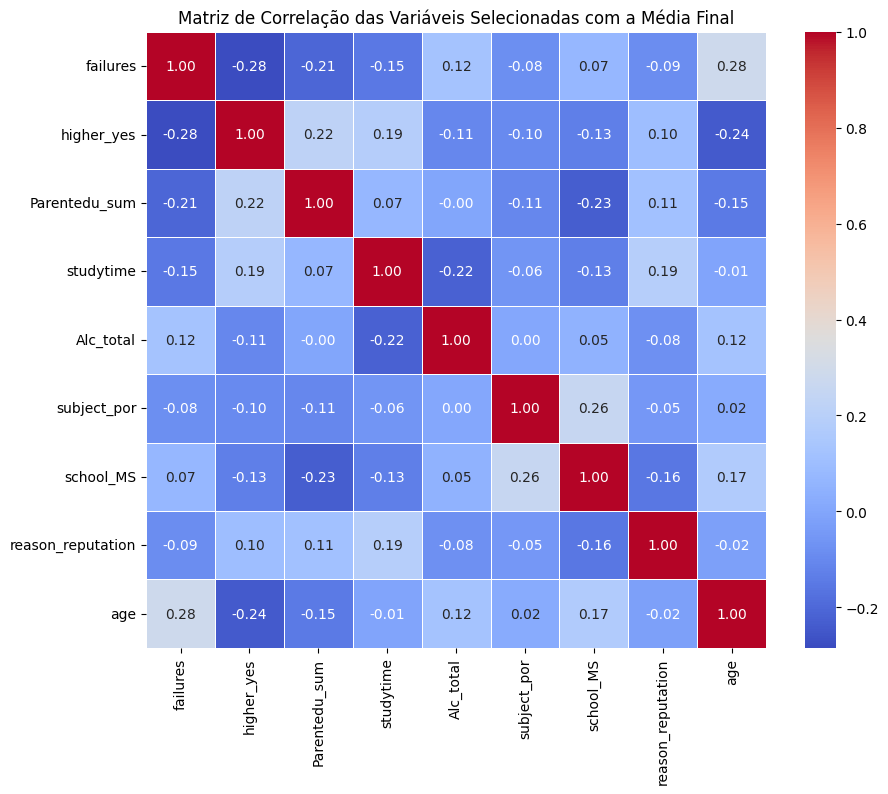

In [78]:

# Usar as variáveis definidas em 'columns_to_plot'
columns_for_corr_matrix = list(columns_to_plot)

# Criar um DataFrame apenas com as colunas selecionadas para calcular a matriz de correlação entre elas
df_selected_features = df_novas_var[columns_for_corr_matrix].copy()

# Calcular a matriz de correlação para as colunas selecionadas
correlation_matrix_top9_features = df_selected_features.corr()

# Plotar o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_top9_features, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Selecionadas com a Média Final')
plt.show()

Pelo que se pode aferir da matriz de correlação não há variáveis indepedentes com altos índeces de correlação, o que valida sua utilização em modelos de regressão linear.

### Criando nova coluna de classificação da média final

Por fim, decidi criar uma nova coluna no *dataframe* em que unifiquei as tabelas de resultados para as matérias português e matemática, a fim de criar uma *target* do tipo categórica.

Assim, classifiquei a média final em **'reprovado'** para nota maior ou igual a 0 e menor ou igual a 9; **'suficiente'** para nota maior ou igual a 10 e menor ou igual a 11; **'satisfatório'** para nota maior ou igual a 12 e menor ou igual a 13; **'bom'** para nota maior ou igual a 14 e menor ou igual a 15; **'excelente'** para nota maior ou igual a 16 e menor ou igual a 20.

Dessa forma, é possivel utilizar os dados para resolver problemas de classificação, inclsuive com utilização de aprendizado não superviosionado, com o objetivo de identificar os hábitos e contextos dos alunos enquadrados nas diferentes categorias de resultado de avaliação.

In [79]:
# Função para classificar a média final
def classificar_media(media):
    if 0 <= media <= 9:
        return 'reprovado'
    elif 10 <= media <= 11:
        return 'suficiente'
    elif 12 <= media <= 13:
        return 'satisfatório'
    elif 14 <= media <= 15:
        return 'bom'
    elif 16 <= media <= 20:
        return 'excelente'
    else:
        return 'não classificado'

df_combinado['classificacao_media_final'] = df_combinado['media final'].apply(classificar_media)

print("Nova coluna 'classificacao_media_final' criada com sucesso.")
display(df_combinado.head())

Nova coluna 'classificacao_media_final' criada com sucesso.


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,G1,G2,G3,subject,media final,classificacao_media_final
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,1,1,3,6,5,6,6,mat,6.0,reprovado
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,1,1,3,4,5,5,6,mat,5.0,reprovado
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,3,3,10,7,8,10,mat,8.0,reprovado
3,GP,F,15,U,GT3,T,4,2,health,services,...,1,1,5,2,15,14,15,mat,15.0,bom
4,GP,F,16,U,GT3,T,3,3,other,other,...,1,2,5,4,6,10,10,mat,9.0,reprovado


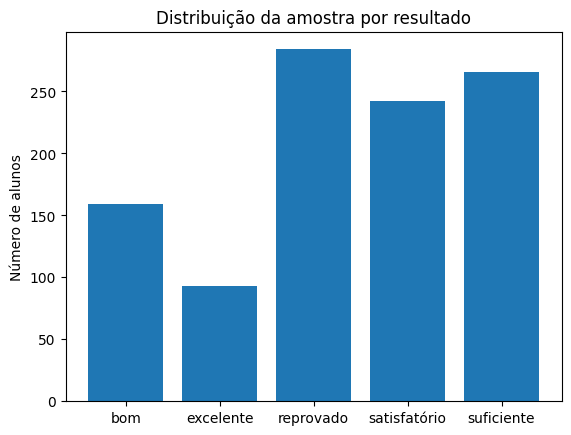

In [80]:
resultado_counts = df_combinado['classificacao_media_final'].value_counts().sort_index()
plt.bar(resultado_counts.index, resultado_counts.values)
plt.title('Distribuição da amostra por resultado')
plt.ylabel('Número de alunos')
plt.show()

Pelo gráfico acima, percebemos que há um desbalanceamento da base de dados para a aplicação de algoritmos de machine learning, especialmente os de classificação, que são mais sensíveis a essa situação.

### Preparação dos Dados para aplicação de algoritmos de machine learning

Agora que criamos a variável `classificacao_media_final`, vamos preparar os dados para a aplicação de algoritmos de Machine Learning. Isso envolve codificar a variável alvo, selecionar as features (removendo as notas originais e variáveis redundantes), escalar os dados e dividi-los para treinamento e teste.

In [81]:


# Adicionar a nova coluna 'classificacao_media_final' ao DataFrame df_novas_var para uso interno
df_novas_var['classificacao_media_final'] = df_combinado['classificacao_media_final']

# Definir as features (X) e a variável alvo para classificação (y_classification)
features_to_drop_from_X = [
    'G1', 'G2', 'G3', 'media final', 'classificacao_media_final',
    'Parentedu_sum' # Removendo Parentedu_sum para evitar multicolinearidade perfeita com Parentedu_avg/max
]

# Criando X a partir de df_novas_var
X = df_novas_var.drop(columns=features_to_drop_from_X, errors='ignore')
y_classification = df_novas_var['classificacao_media_final']


# 1. Codificação da variável alvo 'classificacao_media_final'
label_encoder = LabelEncoder()
y_classification_encoded = label_encoder.fit_transform(y_classification)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Mapeamento da Classificação: {class_mapping}")

# 2. Escalonamento das features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled_df.head())

display(pd.Series(y_classification_encoded).head())

Mapeamento da Classificação: {'bom': np.int64(0), 'excelente': np.int64(1), 'reprovado': np.int64(2), 'satisfatório': np.int64(3), 'suficiente': np.int64(4)}


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,nursery_yes,higher_yes,internet_yes,romantic_yes,subject_por,Alc_total,Parentedu_avg,Parentedu_max,school_history,failures_with_schoolsup
0,1.027889,1.242077,1.466302,0.652210,0.035606,-0.403106,0.068788,-0.195099,0.732511,-0.542374,...,0.500299,0.305276,-1.952194,-0.742471,-1.28181,-0.894969,1.493104,1.125031,-1.580073,-0.126785
1,0.221035,-1.426089,-1.262431,-0.715074,0.035606,-0.403106,1.140653,-0.195099,-0.135527,-0.542374,...,-1.998803,0.305276,0.512244,-0.742471,-1.28181,-0.894969,-1.484547,-1.702896,-0.206554,-0.126785
2,-1.392674,-1.426089,-1.262431,-0.715074,0.035606,4.171268,0.068788,-0.195099,-1.003566,0.554987,...,0.500299,0.305276,0.512244,-0.742471,-1.28181,0.614478,-1.484547,-1.702896,2.540484,12.282262
3,-1.392674,1.242077,-0.352853,-0.715074,1.234713,-0.403106,-1.003076,-1.165019,-1.003566,-0.542374,...,0.500299,0.305276,0.512244,1.346854,-1.28181,-0.894969,0.500553,1.125031,-0.206554,-0.126785
4,-0.585820,0.352689,0.556724,-0.715074,0.035606,-0.403106,0.068788,-0.195099,-1.003566,-0.542374,...,0.500299,0.305276,-1.952194,-0.742471,-1.28181,-0.391820,0.500553,0.182389,-0.206554,-0.126785


,0
0,2
1,2
2,2
3,0
4,2


## Conclusão

O trabalho conseguiu preparar os dados obtidos para análise exploratória, além de identificar possíveis variáveis a serem utilizadas em modelos estatísticos e de *machine learning* para resolver problemas de regressão e, por fim, também foi preparada a base para resolução de problemas de classificação.

A hipótese inicial de que o tempo de estudo, o suporte familiar e a frequência as aulas seriam variáveis com maior influência nos resultados obtidos não se mostrou tão evidente, ao menos para uma análise de correlação linear.

Assim, a base está preparada para aplicação de diversos algoritmos com o objetivo de extrair informações úteis e relevantes dos dados obtidos.